<a href="https://colab.research.google.com/github/Amjad-Bin-Aslam/Data-Analysis-Portfolio/blob/main/06_Matplotlib/02_Matplotlib_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# import Datasets
iris = pd.read_csv('/content/iris.csv')
batter = pd.read_csv('batter.csv')
season_record = pd.read_csv('batsman_season_record.csv')
matches = pd.read_csv('IPL_Ball_by_Ball_2008_2022.csv')

# Colored Scatterplots

In [3]:
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
iris['Species'] = iris['Species'].replace({'Iris-setosa': 0 ,'Iris-versicolor': 1, 'Iris-virginica': 2 })

iris.sample(5)

/tmp/ipython-input-171/2025936963.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iris['Species'] = iris['Species'].replace({'Iris-setosa': 0 ,'Iris-versicolor': 1, 'Iris-virginica': 2 })


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
137,138,6.4,3.1,5.5,1.8,2
126,127,6.2,2.8,4.8,1.8,2
73,74,6.1,2.8,4.7,1.2,1
26,27,5.0,3.4,1.6,0.4,0
28,29,5.2,3.4,1.4,0.2,0


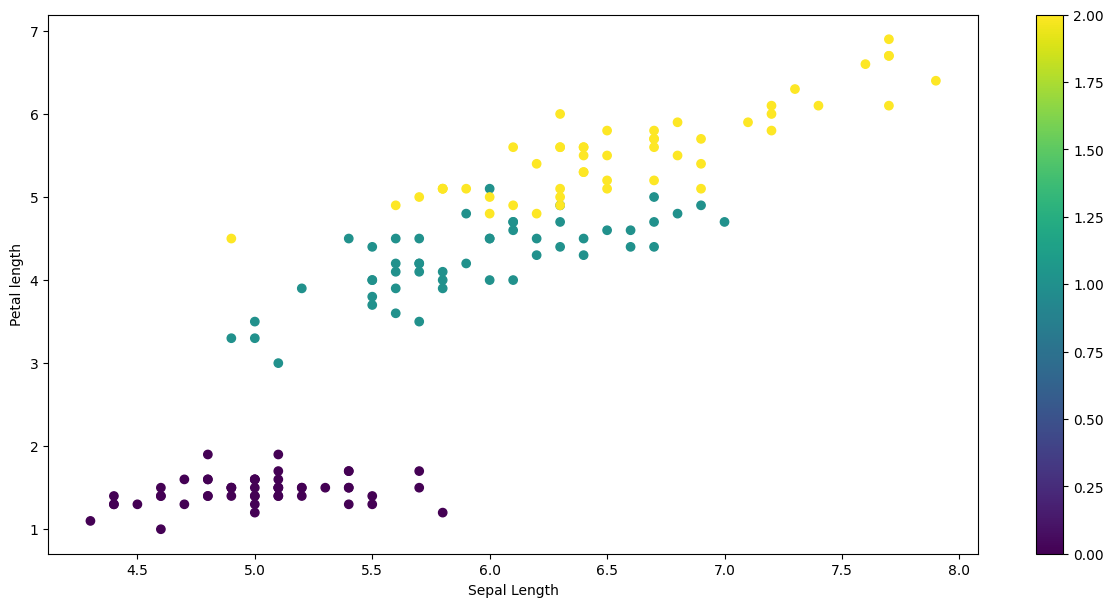

In [5]:
# plot size
plt.figure(figsize=(15,7))

plt.scatter(iris['SepalLengthCm'],iris['PetalLengthCm'], c=iris['Species'])

plt.xlabel("Sepal Length")
plt.ylabel('Petal length')
plt.colorbar()
plt.show()

# Annotation

In [6]:
df = batter.head(100).sample(25,random_state=5)

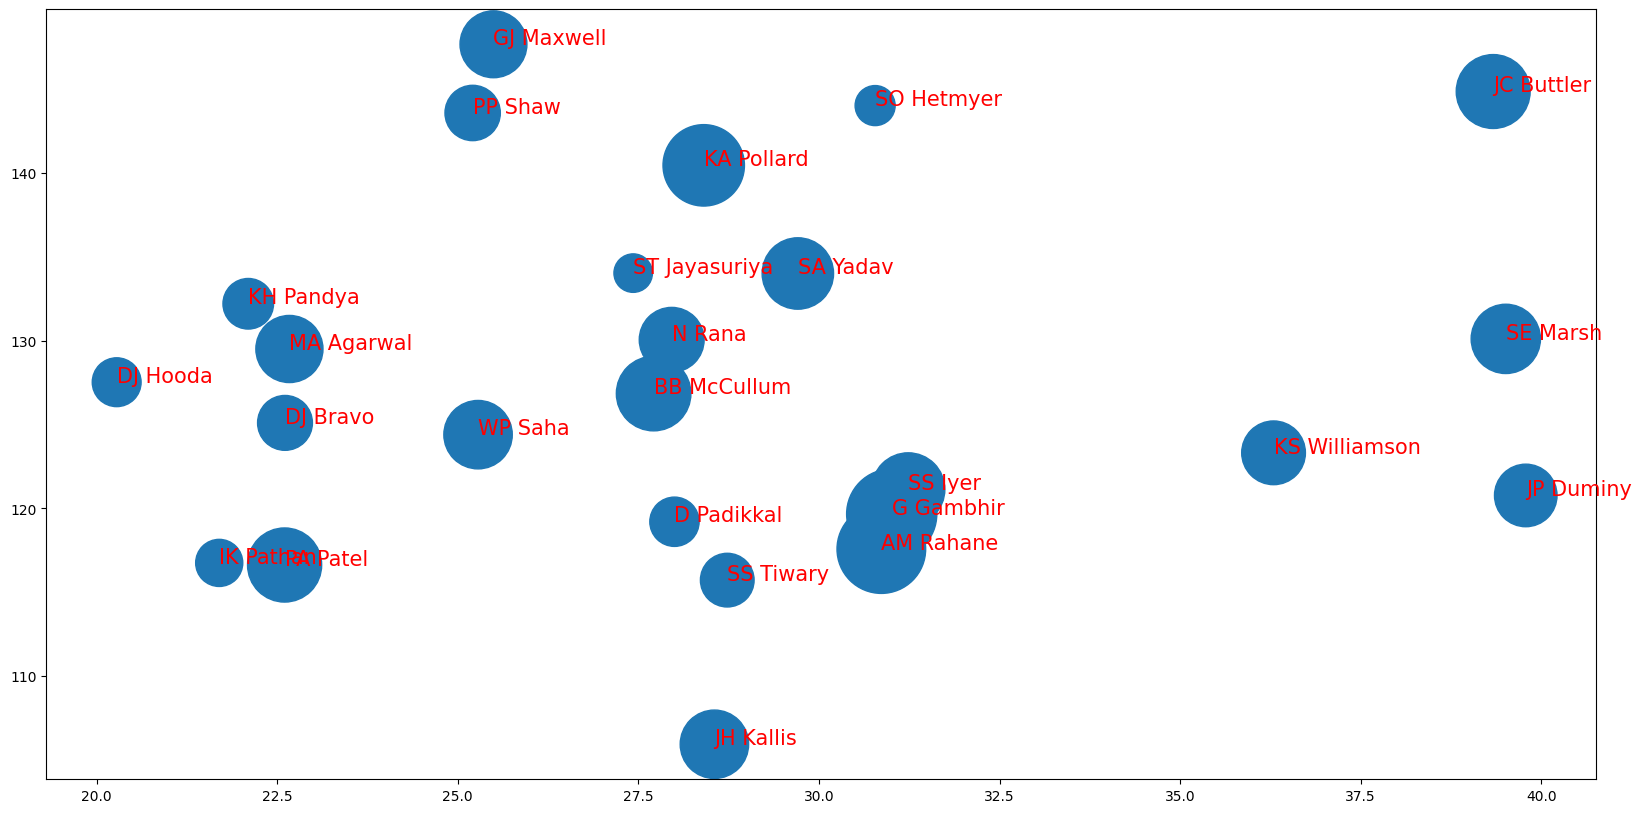

In [7]:
plt.figure(figsize=(20,10))
plt.scatter(df['avg'],df['strike_rate'], s=df['runs'])

for i in range(df.shape[0]):
  plt.text(df['avg'].values[i],df['strike_rate'].values[i],df['batter'].values[i],fontdict={'size': 15,'color': 'red'})

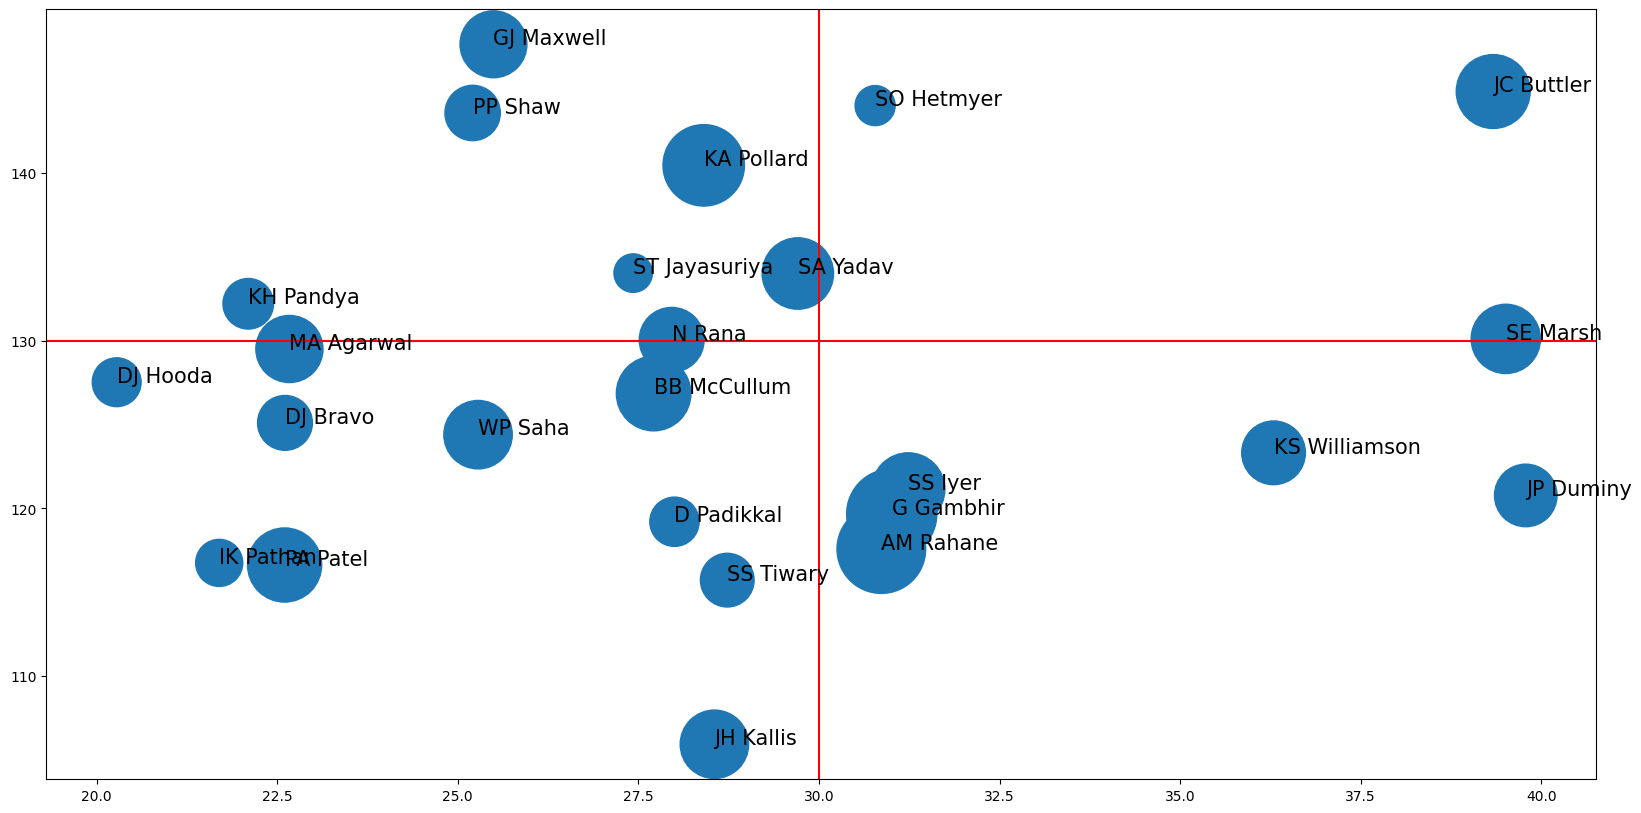

In [8]:
# Horizontal and Vertical lines
plt.figure(figsize=(20,10))
plt.scatter(df['avg'],df['strike_rate'], s=df['runs'])

plt.axhline(130,color='red')
plt.axvline(30,color='red')

for i in range(df.shape[0]):
  plt.text(df['avg'].values[i],df['strike_rate'].values[i],df['batter'].values[i],fontdict={'size': 15})

In [9]:
batter.head(5)

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312


# Subplots

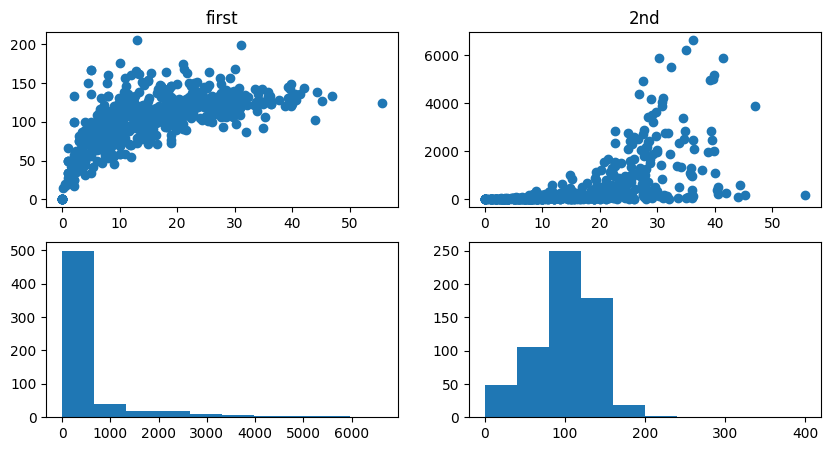

In [29]:
fig, ax = plt.subplots(2,2,figsize=(10,5))

# first plot
ax[0,0].scatter(batter['avg'],batter['strike_rate'])
ax[0,0].set_title('first')

# 2nd plot
ax[0,1].scatter(batter['avg'],batter['runs'])
ax[0,1].set_title('2nd')

# 3rd plot
ax[1,0].hist(batter['runs'])

# 4th plot
ax[1,1].hist(batter['strike_rate'])

fig.show()

# 3D Scatter Plot

Text(0.5, 0, 'Strike Rate')

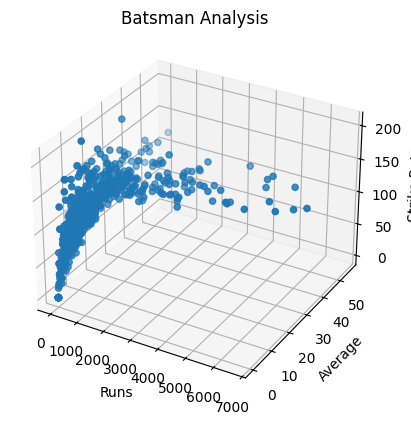

In [38]:
fig = plt.figure()

ax = plt.subplot(projection='3d')

ax.scatter3D(batter['runs'],batter['avg'],batter['strike_rate'])

ax.set_title('Batsman Analysis')
ax.set_xlabel('Runs')
ax.set_ylabel('Average')
ax.set_zlabel('Strike Rate')

# 3D Line plot

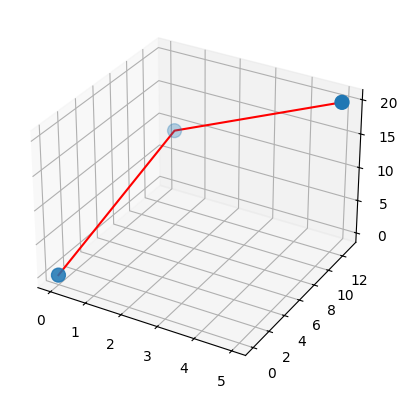

In [42]:
x = [0,1,5]
y = [0,10,13]
z = [0,13,20]

fig = plt.figure()

ax = plt.subplot(projection='3d')

ax.scatter3D(x,y,z, s=[100,100,100])
ax.plot3D(x,y,z, color='red')

# 3D Surface Plot

In [50]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

xx,yy = np.meshgrid(x,y)

In [60]:
z = xx**2 + yy**2

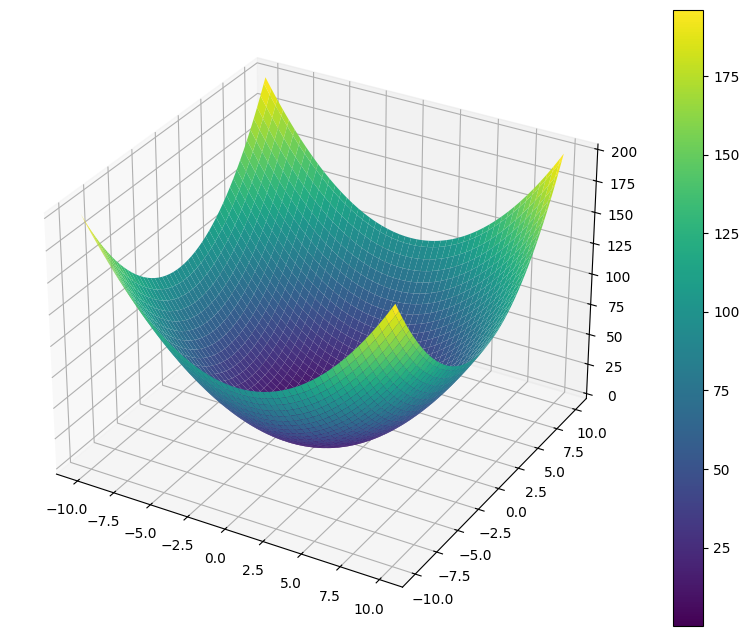

In [64]:
fig = plt.figure(figsize=(12,8))

ax = plt.subplot(projection='3d')

surface = ax.plot_surface(xx,yy,z,cmap='viridis')

fig.colorbar(surface)

# Heatmap

In [81]:
# find the number of sixes ont he each ball of over
temp_df = matches[(matches['ballnumber'].isin([1,2,3,4,5,6])) & (matches['batsman_run'] == 6)]
grid = temp_df.pivot_table(index='overs',columns='ballnumber',values='batsman_run',aggfunc='count')
grid

ballnumber,1,2,3,4,5,6
overs,,,,,,
0,9,17,31,39,33,27
1,31,40,49,56,58,54
2,75,62,70,72,58,76
3,60,74,74,103,74,71
4,71,76,112,80,81,72
5,77,102,63,86,78,80
6,34,56,49,59,64,38
7,59,62,73,70,69,56
8,86,83,79,81,73,52


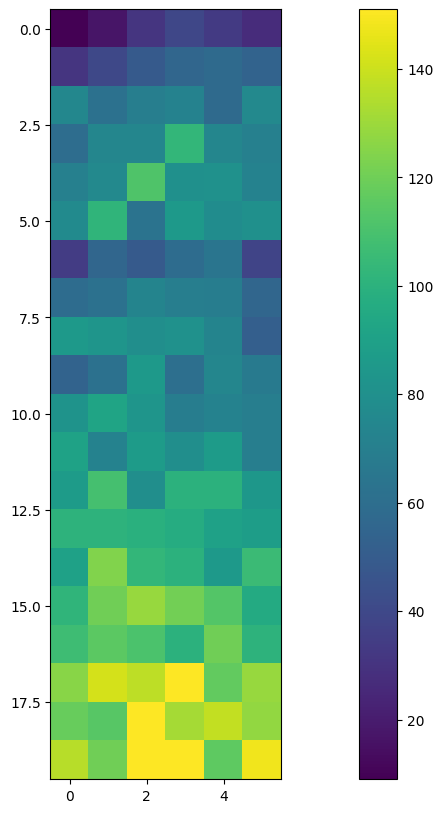

In [82]:
plt.figure(figsize=(20,10))

plt.imshow(grid)

plt.colorbar()

## Pandas Plot()

<Axes: >

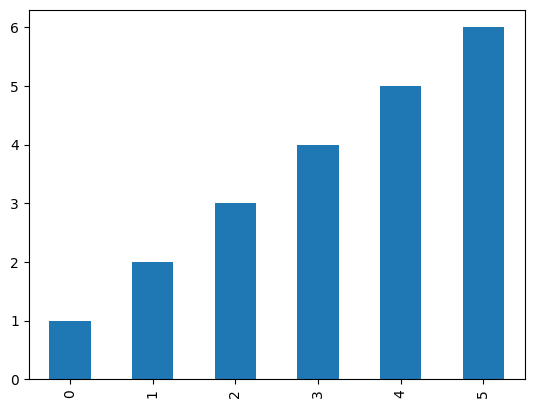

In [90]:
# on series
x = pd.Series([1,2,3,4,5,6])

x.plot(kind='bar')

In [94]:
import seaborn as sns
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: title={'center': 'Tips Analysis'}, xlabel='Total bill', ylabel='Tips'>

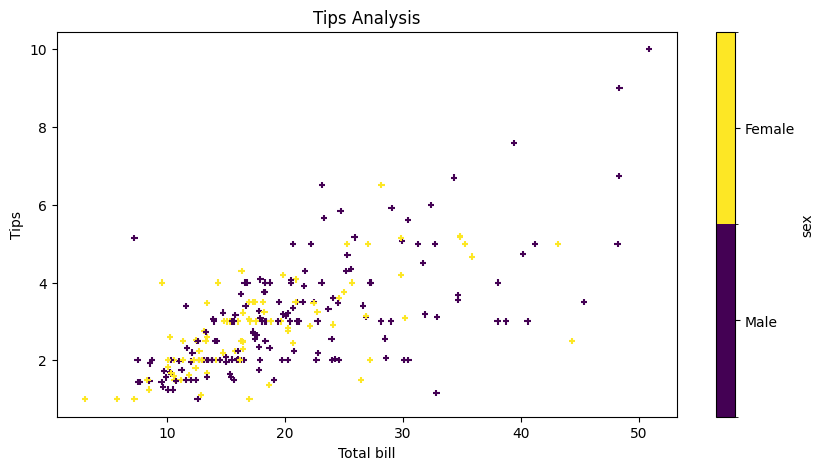

In [106]:
# scatter plot
tips.plot(kind='scatter',x='total_bill',y='tip',title='Tips Analysis',ylabel='Tips',xlabel='Total bill',c='sex',cmap='viridis',marker='+',figsize=(10,5))